In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

1) load data

In [ ]:
df = pd.read_csv("D:/Semester 6/Intelligent Programming/project 1/cleaned_data.csv")

print("Data Loaded Successfully")

Data Loaded Successfully


2)  data overview

In [104]:
print("Shape of data:", df.shape)

Shape of data: (1025, 14)


In [105]:
print("\n First 5 Rows:")
display(df.head())


 First 5 Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1.0,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0.0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1.0,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1.0,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1.0,106,0,1.9,1,3,2,0


In [106]:
print("\n Data Info:")
display(df.info())


 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1024 non-null   float64
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1023 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(2), int64(12)
memory usage: 112.2 KB


None

In [107]:
print("\n Statistical Summary:")
display(df.describe())


 Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1024.000000,1025.000000,1025.000000,1023.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529297,149.114146,0.336585,1.072043,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527931,23.005724,0.472772,1.176008,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [108]:
print("\n Data Types:")
print(df.dtypes)


 Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg     float64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [109]:
print("\n Unique values in each column:")
for col in df.columns:
    print(col, ":", df[col].nunique())


 Unique values in each column:
age : 41
sex : 2
cp : 4
trestbps : 49
chol : 152
fbs : 2
restecg : 3
thalach : 91
exang : 2
oldpeak : 40
slope : 3
ca : 5
thal : 4
target : 2


In [110]:
# check missing values
print("\n Missing Values in each column:")
display(df.isnull().sum())


 Missing Values in each column:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     1
thalach     0
exang       0
oldpeak     2
slope       0
ca          0
thal        0
target      0
dtype: int64

In [111]:
# Check empty strings 
print("\n Checking empty values:")
display((df == "").sum())


 Checking empty values:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [112]:
# check duplicatesd
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)


Number of duplicate rows: 720



Column: chol
Detected outliers: 16


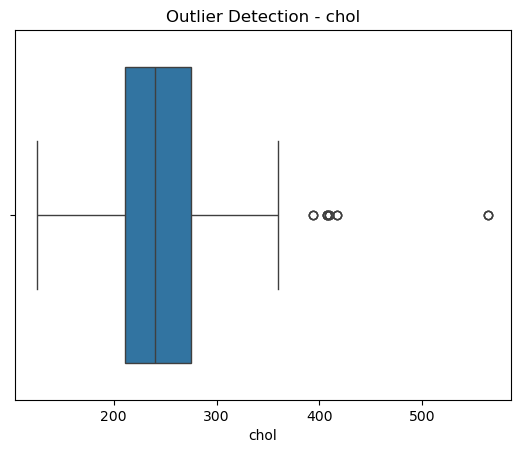


Column: trestbps
Detected outliers: 30


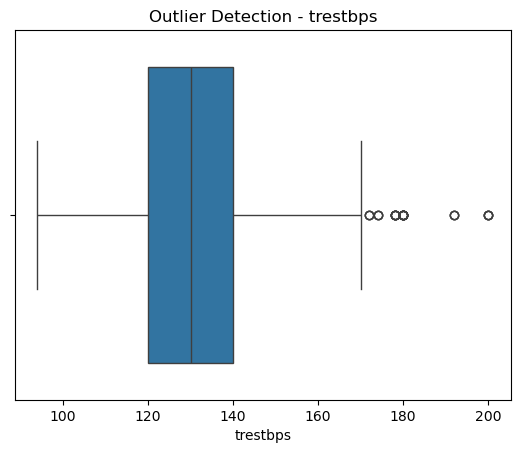


Column: thalach
Detected outliers: 4


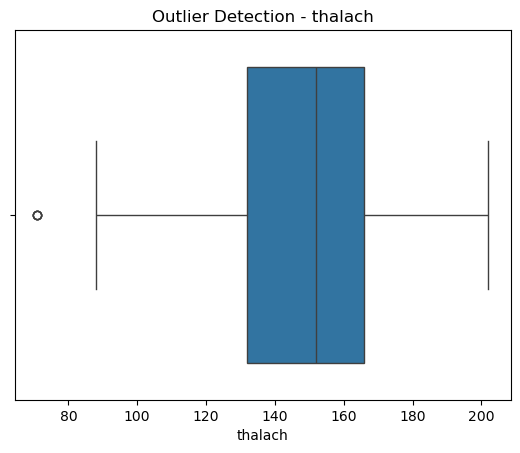


Column: oldpeak
Detected outliers: 7


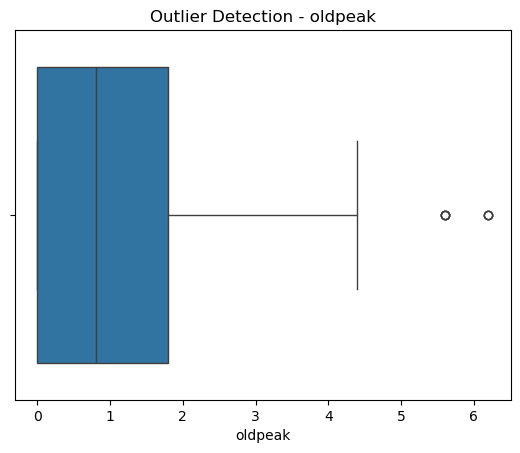

In [113]:
cols = ['chol', 'trestbps', 'thalach', 'oldpeak']

for col in cols:
    print(f"\nColumn: {col}")
    
    # IQR calculation
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print("Detected outliers:", outliers.shape[0])

    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection - {col}")
    plt.show()

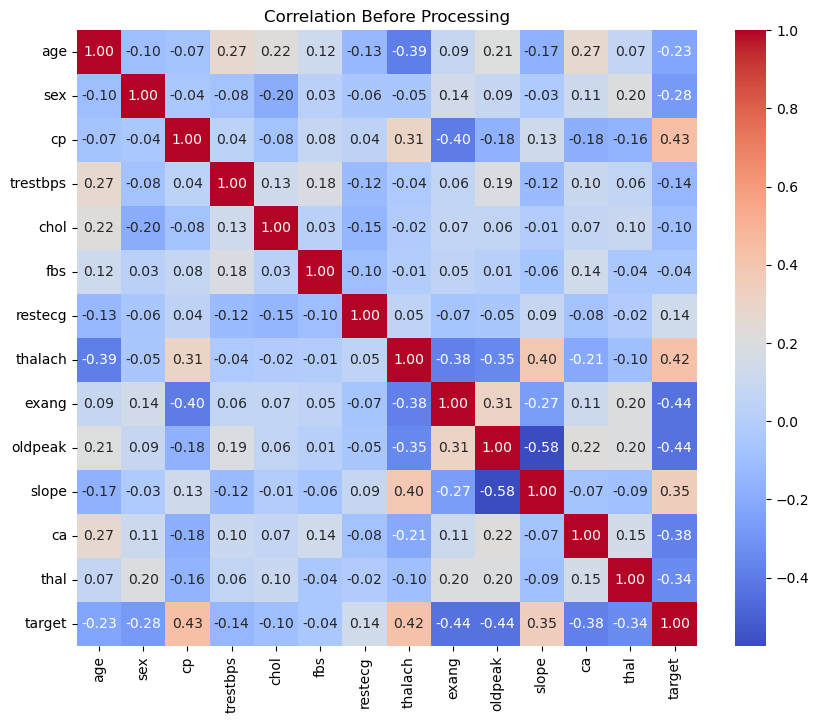

In [114]:
# correlation before cleaning 
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Before Processing")
plt.show()

Data Cleaning

In [115]:
#remove duplicates
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (305, 14)


In [116]:
# Handle Missing Values

df['restecg'] = df['restecg'].fillna(df['restecg'].mode()[0])
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())
print("Missing values handled")

Missing values handled


In [117]:
# Fix data types

df['restecg'] = df['restecg'].astype(int)
df['oldpeak'] = df['oldpeak'].astype(float)

In [118]:
cols = ['chol', 'trestbps', 'thalach', 'oldpeak']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outliers handled using IQR clipping ")

Outliers handled using IQR clipping 


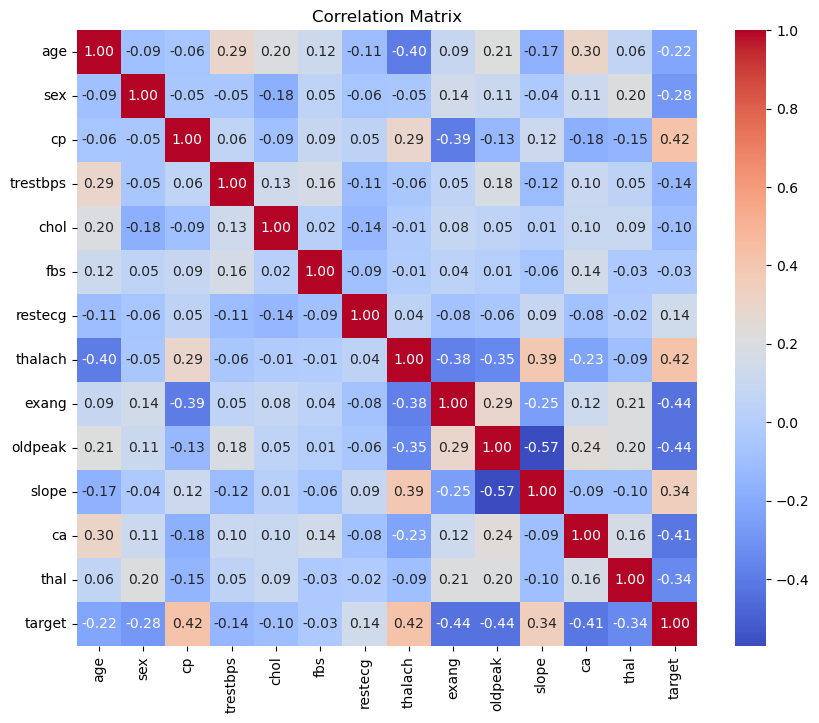


Feature Correlation with Target:
target      1.000000
thalach     0.419539
cp          0.419328
slope       0.344079
restecg     0.136667
fbs        -0.034660
chol       -0.102265
trestbps   -0.136883
age        -0.222436
sex        -0.284274
thal       -0.341258
ca         -0.413055
exang      -0.435867
oldpeak    -0.436255
Name: target, dtype: float64


In [119]:
# FEATURE SELECTION 

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

print("\nFeature Correlation with Target:")
print(df.corr(numeric_only=True)['target'].sort_values(ascending=False))

In [120]:
#  ENCODING CATEGORICAL VARIABLES
df = pd.get_dummies(df, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=True)

print("\nAfter Encoding Shape:", df.shape)


After Encoding Shape: (305, 20)


In [121]:
# NORMALIZATION (MINMAX SCALING)

scaler = MinMaxScaler()

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

df[num_cols] = scaler.fit_transform(df[num_cols])

print("Data Normalized")

Data Normalized


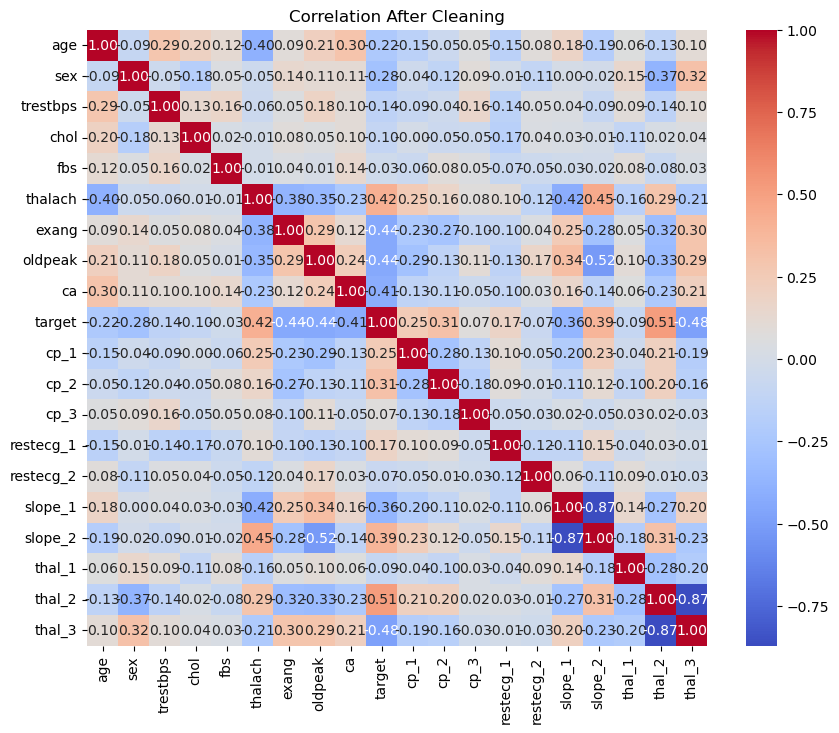

In [122]:
# Correlation After Cleaning
plt.figure(figsize=(10,8))

corr_after = df.corr(numeric_only=True)

sns.heatmap(corr_after, cmap="coolwarm", annot=True, fmt=".2f")

plt.title("Correlation After Cleaning")
plt.show()

In [123]:
print("\nFinal Dataset Shape:", df.shape)
print("\nFinal Missing Values Check:")
print(df.isnull().sum())


Final Dataset Shape: (305, 20)

Final Missing Values Check:
age          0
sex          0
trestbps     0
chol         0
fbs          0
thalach      0
exang        0
oldpeak      0
ca           0
target       0
cp_1         0
cp_2         0
cp_3         0
restecg_1    0
restecg_2    0
slope_1      0
slope_2      0
thal_1       0
thal_2       0
thal_3       0
dtype: int64


In [124]:
# Save clean data

df.to_csv("cleaned_data.csv", index=False)
print("Cleaned data saved successfully ")

Cleaned data saved successfully 
